In [11]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from wave_approx import *
from reduced_model_utils import *
import pickle
import matplotlib.gridspec as gs
import matplotlib as mpl

%load_ext autoreload
%autoreload 2
mpl.rcParams.update({'font.family': 'CMU Sans Serif', 'axes.unicode_minus' : False})
mpl.rcParams.update({'mathtext.fontset': 'cm', 'mathtext.default':'it'})
def get_colors(n, sat0 = 0.3, val0 = 0.1, val1 = 1.0, sat_mode = False, g_sat_scale = 0.8):
    sat_green = np.zeros((n,3))
    sat_red = np.zeros((n,3))
    sat_blue = np.zeros((n,3))
    sat_green[:,0] = 1/3
    sat_red[:,0] = 0
    sat_blue[:,0] = 1.8/3 

    if sat_mode:
        sat_green[:,1] = np.linspace(sat0, 1, n)*g_sat_scale
        sat_green[:,2] = val1
    else:
        sat_green[:,1] = sat0*g_sat_scale
        sat_green[:,2] = np.power(np.linspace(val0, val1, n), 1)

    if sat_mode:
        sat_red[:,1] = np.linspace(sat0, 1, n)
        sat_red[:,2] = val1
    else:
        sat_red[:,1] = sat0
        sat_red[:,2] = np.power(np.linspace(val0, val1, n), 1)

    if sat_mode:
        sat_blue[:,1] = np.linspace(sat0, 1, n)
        sat_blue[:,2] = val1
    else:
        sat_blue[:,1] = sat0
        sat_blue[:,2] = np.power(np.linspace(val0, val1, n), 1)
    greens = mpl.colors.hsv_to_rgb(sat_green)
    reds = mpl.colors.hsv_to_rgb(sat_red)
    blues = mpl.colors.hsv_to_rgb(sat_blue)
    blacks = np.tile(np.linspace(val0, val1-val0, n), (3,1)).T
    return greens, reds, blues, blacks

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
quad = False
rLTD = 0.3
r0 = 6
rx = 20
l = 8
#d = 15/20*8
d = 10/20*l
#d = 5/20*8
v = 3.2
k = 0.114*0.017
A = 0.001
tau_m = 0.02
tau = 1
gL = 40
w0 = 0.06581
cap = 0
shape = 'circle'
match shape:
    case 'circle':
        half_func = half_circle_height
        iint_func = iint_circle_chord
        int_func = int_circle_chord
        if quad:
            func = half_circle_height
        else:
            func = iint_circle_chord
    case 'square':
        half_func = half_square
        iint_func = iint_square
        int_func = int_square
        if quad:
            func = half_square
        else:
            func = iint_square
 

[0.0125 0.0125 0.0125 0.0125 0.0125]


TypeError: iter_sweep() got an unexpected keyword argument 'G_perc'

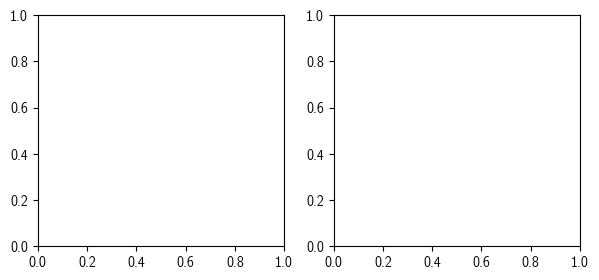

In [69]:
theme = 'speed-same_sweep'
method = 'exact2'
approx_only = False 
d = 4
v_range = np.array([1.6,3.2,6.4,9.6,12.8])
nT_range = np.array([100,100,100,100,100])*4
#w_range = 0.15*np.ones(nT_range.size)
w_range = np.array([0.02,0.04,0.08,0.12,0.16])
#nT_range = np.array([50,100,200,300,400])
print(w_range/v_range)
#w_range = [w_range[0], w_range[-1]]
#v_range = [v_range[0], v_range[-1]]
#nT_range = [nT_range[0], nT_range[-1]]
fork_ivp = True 
k = 0.114*0.017
A = 0.01
r0 = 6
rLTD = 0.3
dT = 1
dt = 5e-3
wt_v = [[],[]]
fr_v = [[],[]]
nx = 101
i = 0
norm_w = 2
L = l*2*np.sqrt(2) + 2*d
x = np.linspace(0,2*l,nx)
fig, ax = plt.subplots(1, 2, figsize = (7,3))
for _v in v_range:
    _nT = nT_range[i]
    _w = w_range[i]
    T = L/_v
    nt = int(T/dt)
    if not approx_only:
        wt1, fr1, rbar1 = iter_sweep(method, nT = _nT, w0 = _w, l = l, d = d, v = _v, k = k, A = A*_w, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, nt = nt, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, G_perc = 1.0, dt = dt, reset_fr = False)
    wt2, fr2, rbar2 = iter_sweep('approx2', nT = dT*_nT, w0 = _w, l = l, d = d, v = _v, k = k, A = A/dT*_w, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, nt = nt, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, G_perc = 1.0, dt = dt, reset_fr = True)
    i += 1
    nx = wt1.shape[0]
    if not approx_only:
        wt_v[0].append(wt1[:,-1])
        ax[0].plot(x, wt1[:,-1], label = f'{method}-{i}')
        ax[1].plot((np.arange(_nT)+1)*T/60, [np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT)], label = f'{method}-{i}')
        fr_v[0].append([np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT)])
        
    wt_v[1].append(wt2[:,-1])
    ax[0].plot(x, wt2[:,-1], ':', label = f'approx2-{i}')
    ax[1].plot((np.arange(_nT*dT)/dT + 1)*T/60, [np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)], label = f'approx2-{i}')
    fr_v[1].append([np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)])
ax[1].legend()
ax[1].set_xlabel('t (min)')
#fig.savefig(f'{theme}-homeo{norm_w}_temp.svg')
fig.savefig(f'{theme}-homeo{norm_w}_temp.png')
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'wb') as f:
    pickle.dump([w_range, nT_range, v_range, L, l, nx, dT, wt_v, fr_v], f)

In [ ]:
theme = 'width-same_per_t'
l = 8
deg_r = 10
v = 3.2
d_range = np.array([2.5,3.75,5,6.25,7.5])
#w_range = np.array([1.0, 0.66666667, 0.5, 0.4, 0.33333333])/10
w_range = np.array([1.0, 0.71674037, 0.57511055, 0.49013266, 0.43348074])*0.08
#nT_range = np.array([100, 100, 100, 100, 100])*5
v_range = np.ones(d_range.size)*v
T_range = (2*l*np.sqrt(2) + 2*d_range/deg_r*l)/v_range
standard_nT = 500
nT_range = np.round(standard_nT*T_range[2]/T_range).astype(int)
print(T_range)
print(nT_range)
print(T_range*nT_range)
fork_ivp = True 
dT = 1
dt = 5e-3
k = 0.114*0.017
A = 0.04
gL = 40
wt = [[],[]]
fr = [[],[]]
nx = 101
i = 0
fig, ax = plt.subplots(1, 2, figsize = (7,3))
x = np.linspace(0,2*l,nx)
for _d in d_range:
    __d = _d/deg_r*l
    print(__d)
    _nT = nT_range[i]
    _w0 = w_range[i]
    L = l*2*np.sqrt(2) + 2*__d
    T = L/v
    nt = int(T/dt)
    wt1, fr1, rbar1 = iter_sweep('exact2', nT = _nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = 2, nt = nt, reset_fr = False)
    wt2, fr2, rbar2 = iter_sweep('approx2', nT = dT*_nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0/dT, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = 2, nt = nt, reset_fr = True)
    i += 1
    wt[0].append(wt1[:,-1])
    wt[1].append(wt2[:,-1])
    nx = wt1.shape[0]
    ax[0].plot(x, wt1[:,-1], label = 'exact2')
    ax[0].plot(x, wt2[:,-1], ':', label = 'approx2')
    ax[0].legend()
    ax[1].plot(np.arange(_nT), [np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT)], label = 'exact2')
    ax[1].plot(np.arange(_nT*dT)/dT, [np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)], label = 'approx2, norm. t')
    fr[0].append([np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT)])
    fr[1].append([np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)])
    
ax[1].legend()
fig.savefig(f'{theme}-exact2_vs_approx2_homeo2_temp.png')

with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'wb') as f:
    pickle.dump([w_range, nT_range, d_range, deg_r, l, nx, dT, wt, fr], f)

T = 9.571, dt = 5.001e-03, each LGN activated for 26.1%
no cap on weight
using method approx2
r0 * G <= 0.0011781850426671788 < 1, the larger fixed point of the linearized system is always stable
1/400...plot weight at sweep 0
24/400... plot weight at sweep 23
32/400... plot weight at sweep 31
40/400... plot weight at sweep 39
400/400... plot weight at sweep 399
plot sample sweep #0
slice(0, 1915, None)
[0.00000000e+00 5.00055790e-03 1.00011158e-02 ... 9.56106670e+00
 9.56606725e+00 9.57106781e+00]
nan
208:
move from None to Stable
[1.0356711  1.03622672 1.03678234 1.03733795 1.03789357 1.03844919
 1.03900481 1.03956042 1.04011604] 3.2 4.0 8
[0. 0. 0. 0. 0. 0. 0. 0. 0.] [0.00043903 0.002217   0.00399498 0.00577296 0.00755093 0.00932891
 0.01110688 0.01288486 0.01466284]
[1.52126857e-09 1.72625090e-08 4.17553147e-08 7.25308530e-08
 1.08495517e-07 1.48985055e-07 1.93539836e-07 2.41817148e-07
 2.93548606e-07] [0.01072778 0.02410588 0.03235735 0.03889472 0.0444803  0.04943775
 0.05394054 0

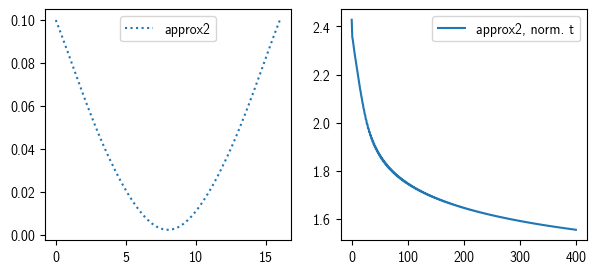

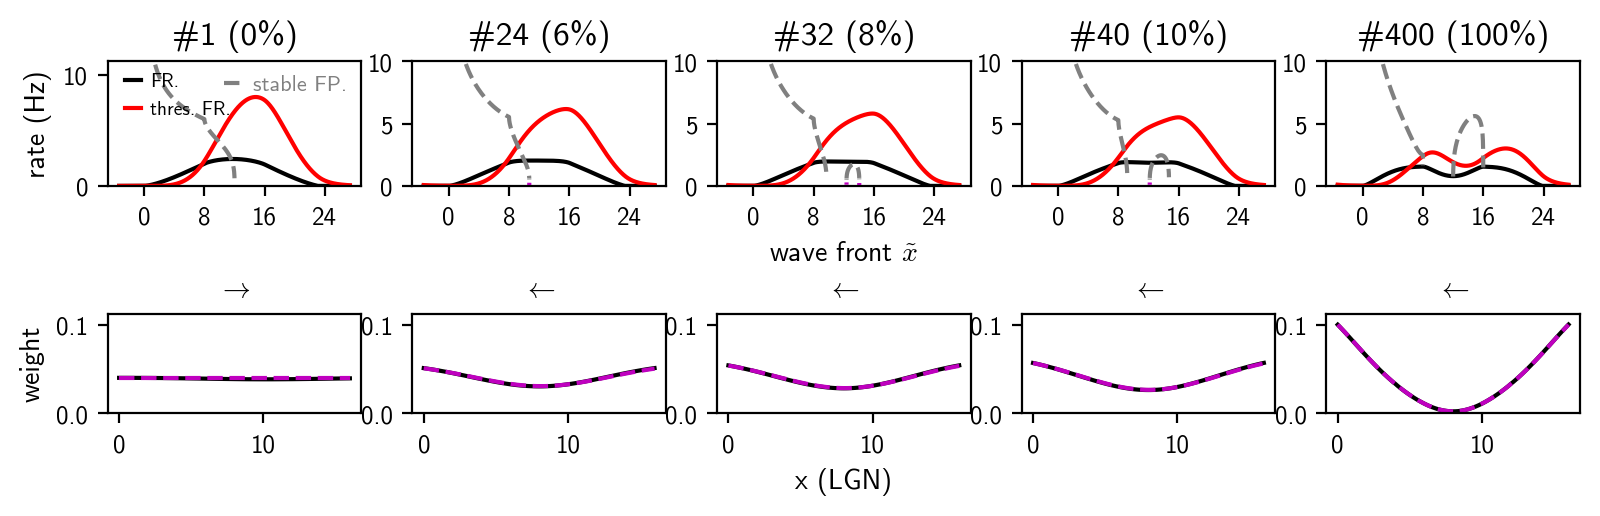

In [32]:
theme = 'ltd_ratio6'
l = 8
deg_r = 10
exact_only = False
approx_only = True 
v = 3.2
#ltd_ratio_range = np.array([0.3, 1.0, 2.0, 3.0, 4.0, 10])
ltd_ratio_range = np.array([10])
d_range = np.zeros(ltd_ratio_range.size) + 5
w_range = np.zeros(ltd_ratio_range.size) + 0.04
nT_0 = 400
nT_range = np.zeros(ltd_ratio_range.size, dtype = int) + nT_0
v_range = np.zeros(ltd_ratio_range.size) + v
#diagram_perc = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
#diagram_perc = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
#diagram_perc = [0.2, 0.3, 1.0]
diagram_perc = [0.0, 0.06, 0.08, 0.1, 1.0]
pd = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
#pd = [0.25,0.4,0.5,0.6,0.75]
#pd = [0.4,0.5,0.6]
fork_ivp = True
dT = 1
dt = 5e-3
k = 0.114*0.017
A = 0.04
gL = 40
wt = [[],[]]
fr = [[],[]]
nx = 101
norm_w = 2
i = 0
fig, ax = plt.subplots(1, 2, figsize = (7,3))
x = np.linspace(0,2*l,nx)
for _d in d_range:
    __d = _d/deg_r*l
    _nT = nT_range[i]
    _w0 = w_range[i]
    _rLTD = ltd_ratio_range[i]
    L = l*2*np.sqrt(2) + 2*__d
    T = L/v
    nt = int(T/dt)
    if not approx_only:
        wt2, fr2, rbar2 = iter_sweep('exact2', nT = _nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = False, diagram_perc = diagram_perc, fs = 10, ls = 8, pdiagram_idx = 1, pd = pd, pscale = 2, less = 1)
        wt[0].append(wt2[:,-1])
        nx = wt2.shape[0]
        ax[0].plot(x, wt2[:,-1], label = 'exact2')
        ax[1].plot(np.arange(_nT), [np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT)], label = 'exact2')
        fr[0].append([np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT)])
    if not exact_only:
        wt1, fr1, rbar1 = iter_sweep('approx2', nT = dT*_nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0/dT, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = True, diagram_perc = diagram_perc, fs = 10, ls = 8, pdiagram_idx = 1, pd = pd, pscale = 2, less = 1)
        wt[1].append(wt1[:,-1])
        ax[0].plot(x, wt1[:,-1], ':', label = 'approx2')
        ax[1].plot(np.arange(_nT*dT)/dT, [np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)], label = 'approx2, norm. t')
        fr[1].append([np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)])
    i += 1
ax[0].legend()
ax[1].legend()
fig.savefig(f'{theme}-exact2_vs_approx2_homeo2_temp.png')

with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'wb') as f:
    pickle.dump([ltd_ratio_range, w_range, nT_range, d_range, deg_r, l, nx, dT, wt, fr], f)

T = 9.571, dt = 5.001e-03, each LGN activated for 26.1%
no cap on weight
using method approx2
r0 * G <= 0.005890925213335895 < 1, the larger fixed point of the linearized system is always stable
1/10...plot weight at sweep 0
10/10...plot weight at sweep 9
plot sample sweep #0
slice(0, 1915, None)
[0.00000000e+00 5.00055790e-03 1.00011158e-02 ... 9.56106670e+00
 9.56606725e+00 9.57106781e+00]
nan
208:
move from None to Stable
[1.0356711  1.03622672 1.03678234 1.03733795 1.03789357 1.03844919
 1.03900481 1.03956042 1.04011604] 3.2 4.0 8
[0. 0. 0. 0. 0. 0. 0. 0. 0.] [0.00043903 0.002217   0.00399498 0.00577296 0.00755093 0.00932891
 0.01110688 0.01288486 0.01466284]
[7.60634286e-09 8.63125452e-08 2.08776574e-07 3.62654265e-07
 5.42477587e-07 7.44925273e-07 9.67699182e-07 1.20908574e-06
 1.46774303e-06] [0.02145555 0.04821176 0.06471471 0.07778945 0.0889606  0.0988755
 0.10788108 0.11618896 0.12393953]
move from None to Stable at 207-1
zoom in current Stable vs. original Stable
zoom in cur

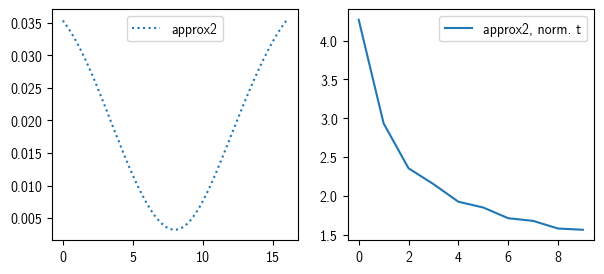

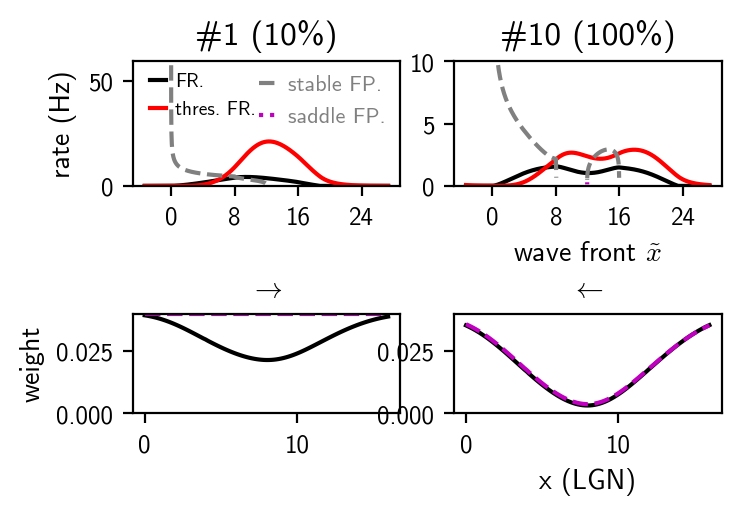

In [34]:
theme = 'ltd_ratio10'
l = 8
deg_r = 10
exact_only = False
approx_only = True
v = 3.2
ltd_ratio_range = np.array([10])
d_range = np.zeros(ltd_ratio_range.size) + 5
w_range = np.zeros(ltd_ratio_range.size) + 0.04
nT_0 = 10
nT_range = np.zeros(ltd_ratio_range.size, dtype = int) + nT_0
v_range = np.zeros(ltd_ratio_range.size) + v
#diagram_perc = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 1.0]
diagram_perc = [0.0, 0.06, 0.08, 0.1, 1.0]
pd = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
#pd = [0.25,0.4,0.5,0.6,0.75]
#pd = [0.4,0.5,0.6]
fork_ivp = True
dT = 1
dt = 5e-3
k = 0.114*0.017
A = 0.1
gL = 20
wt = [[],[]]
fr = [[],[]]
nx = 101
norm_w = 0
i = 0
fig, ax = plt.subplots(1, 2, figsize = (7,3))
x = np.linspace(0,2*l,nx)
for _d in d_range:
    __d = _d/deg_r*l
    _nT = nT_range[i]
    _w0 = w_range[i]
    _rLTD = ltd_ratio_range[i]
    L = l*2*np.sqrt(2) + 2*__d
    T = L/v
    nt = int(T/dt)
    if not approx_only:
        wt2, fr2, rbar2 = iter_sweep('exact2', nT = _nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = False, diagram_perc = diagram_perc, fs = 10, ls = 8, pdiagram_idx = 1, pd = pd, pscale = 4, less = 1)
        wt[0].append(wt2[:,-1])
        nx = wt2.shape[0]
        ax[0].plot(x, wt2[:,-1], label = 'exact2')
        ax[1].plot(np.arange(_nT), [np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT)], label = 'exact2')
        fr[0].append([np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT)])
    if not exact_only:
        wt1, fr1, rbar1 = iter_sweep('approx2', nT = dT*_nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0/dT, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = False, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = True, diagram_perc = diagram_perc, fs = 10, ls = 8, pdiagram_idx = 1, pd = pd, pscale = 4, less = 1)
        wt[1].append(wt1[:,-1])
        ax[0].plot(x, wt1[:,-1], ':', label = 'approx2')
        ax[1].plot(np.arange(_nT*dT)/dT, [np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)], label = 'approx2, norm. t')
        fr[1].append([np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)])
    i += 1
ax[0].legend()
ax[1].legend()
fig.savefig(f'{theme}-exact2_vs_approx2_homeo2_temp.png')

with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'wb') as f:
    pickle.dump([ltd_ratio_range, w_range, nT_range, d_range, deg_r, l, nx, dT, wt, fr], f)

T = 9.571, dt = 3.907e-03, each LGN activated for 26.1%
no cap on weight
using method approx2
r0 * G <= 0.006995473690836374 < 1, the larger fixed point of the linearized system is always stable
1/400...plot weight at sweep 0
52/400... plot weight at sweep 51
60/400... plot weight at sweep 59
68/400... plot weight at sweep 67
400/400... plot weight at sweep 399
plot sample sweep #0
 ymax = 30
max fixed point in coil: (12.00138899850331, 5.926096392620973)
plot sample sweep #51
 ymax = 30
plot sample sweep #59
 ymax = 30
max fixed point in coil: (13.125088787680307, 6.882221016106911)
plot sample sweep #67
 ymax = 30
max fixed point in coil: (13.362607531746198, 9.548211617344856)
plot sample sweep #399
 ymax = 30
max fixed point in coil: (14.550201252075658, 24.29518143947448)


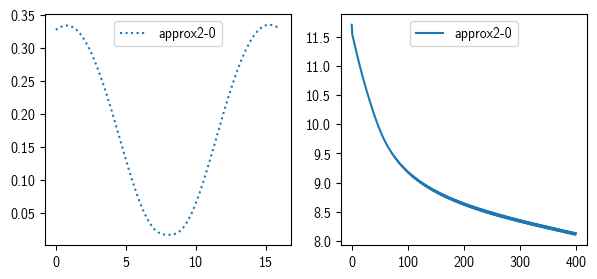

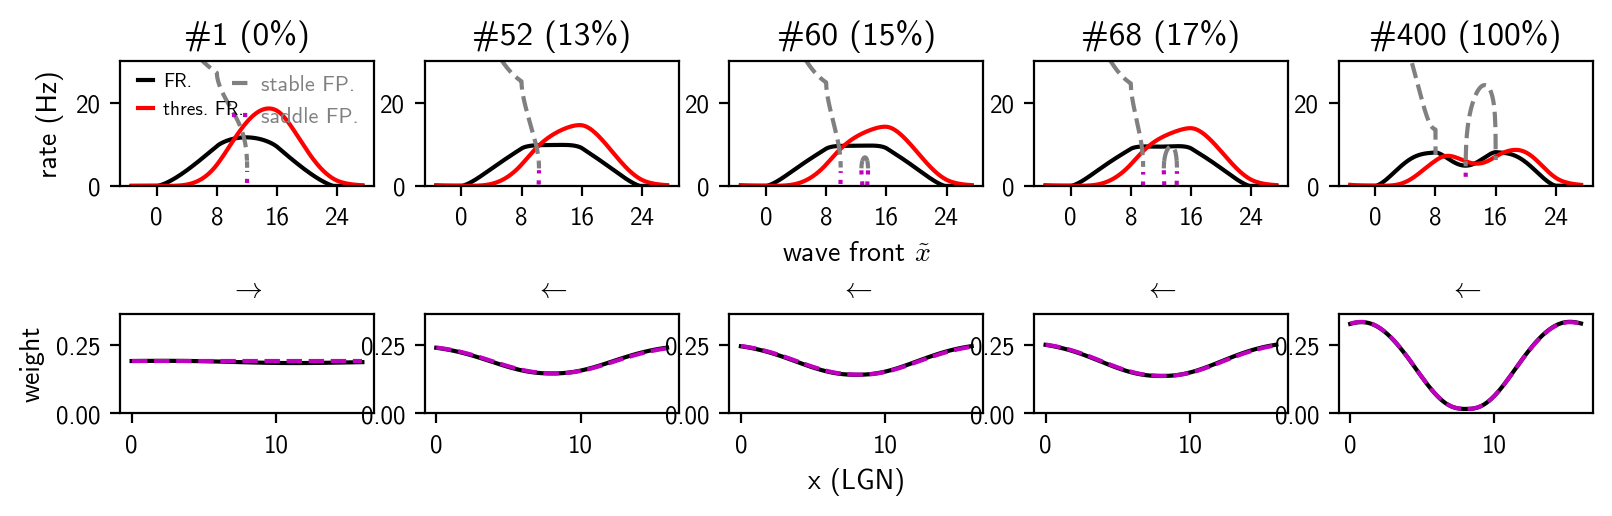

In [43]:
#theme = 'w0_summary6-mechanism'
theme = 'w0_19-mechanism'
#theme = 'w0'
l = 8
deg_r = 10
tplot = False
exact_only = False 
approx_only = True 
#diagram_perc = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 1.0]
diagram_perc = [0.0, 0.13, 0.15, 0.17, 1.0]
pd = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
v = 3.2
#w_range = np.array([0.04, 0.07, 0.1, 0.13, 0.16, 0.19])
w_range = np.array([0.19])
ltd_ratio_range = np.zeros(w_range.size) + 1.0
d_range = np.zeros(w_range.size) + 5
nT_0 = 400
#nT_range = np.array([int(nT_0/w_range[i]*w_range[0]) for i in range(w_range.size)])
nT_range = np.zeros(w_range.size, dtype = int) + nT_0
v_range = np.zeros(w_range.size) + v
fork_ivp = True 
pscale = -30
dT = 1
dt = 1/256
k = 0.114*0.017
A = 0.005
rx = 20
gL = 40
wt = [[],[]]
fr = [[],[]]
nx = 101
i = 0
norm_w = 2
fig, ax = plt.subplots(1, 2, figsize = (7,3))
x = np.linspace(0,2*l,nx)
for _d in d_range:
    __d = _d/deg_r*l
    _nT = nT_range[i]
    _w0 = w_range[i]
    _rLTD = ltd_ratio_range[i]
    L = l*2*np.sqrt(2) + 2*__d
    T = L/v
    nt = int(T/dt)
    if not approx_only:
        wt2, fr2, rbar2 = iter_sweep('exact2', nT = _nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = tplot, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = False, diagram_perc = diagram_perc, fs = 10, ls = 8, pdiagram_idx = 1, pd = pd, pscale = pscale, less = 1)
        wt[0].append(wt2[:,-1])
        nx = wt1.shape[0]
        ax[0].plot(x, wt2[:,-1], label = f'exact2-{i}')
        ax[1].plot(np.arange(_nT), [np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT)], label = f'exact2-{i}')
        fr[0].append([np.max(fr2[j*nt+1:(j+1)*nt+1]) for j in range(_nT)])
    if not exact_only:
        wt1, fr1, rbar1 = iter_sweep('approx2', nT = dT*_nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0/dT, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = tplot, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = True, diagram_perc = diagram_perc, fs = 10, ls = 10, pdiagram_idx = 1, pd = pd, pscale = pscale, less = 1)
        wt[1].append(wt1[:,-1])
        ax[0].plot(x, wt1[:,-1], ':', label = f'approx2-{i}')
        ax[1].plot(np.arange(_nT*dT)/dT, [np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)], label = f'approx2-{i}')
        fr[1].append([np.max(fr1[j*nt+1:(j+1)*nt+1]) for j in range(_nT*dT)])
    i += 1
ax[0].legend(ncols = 3, bbox_to_anchor = (0.5, 1.0), loc = 'upper center')
ax[1].legend(ncols = 3, bbox_to_anchor = (0.5, 1.0), loc = 'upper center')
fig.savefig(f'{theme}-exact2_vs_approx2_homeo2_temp.png')

with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'wb') as f:
    pickle.dump([ltd_ratio_range, w_range, nT_range, d_range, deg_r, l, nx, dT, wt, fr], f)

T = 9.571, dt = 5.001e-03, each LGN activated for 26.1%
no cap on weight
using method approx2
r0 * G <= 0.03681828258334935 < 1, the larger fixed point of the linearized system is always stable
100/100...plot sample sweep #0
slice(0, 1915, None)
[0.00000000e+00 5.00055790e-03 1.00011158e-02 ... 9.56106670e+00
 9.56606725e+00 9.57106781e+00]
nan
208:
move from None to Stable
[1.0356711  1.03622672 1.03678234 1.03733795 1.03789357 1.03844919
 1.03900481 1.03956042 1.04011604] 3.2 4.0 8
[0. 0. 0. 0. 0. 0. 0. 0. 0.] [0.00043903 0.002217   0.00399498 0.00577296 0.00755093 0.00932891
 0.01110688 0.01288486 0.01466284]
[4.75396429e-09 5.39453408e-08 1.30485359e-07 2.26658916e-07
 3.39048492e-07 4.65578295e-07 6.04811989e-07 7.55678586e-07
 9.17339395e-07] [0.02681944 0.06026471 0.08089339 0.09723681 0.11120076 0.12359438
 0.13485135 0.1452362  0.15492442]
move from None to Stable at 207-1
zoom in current Stable vs. original Stable
zoom in current g = 9.173393949469456e-07 vs. 9.17339394946945

/opt/miniconda3/envs/general/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/general/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


938:
move from Stable to Saddle+Stable
[4.68607837 4.68663398 4.6871896  4.68774522 4.68830084 4.68885645
 4.68941207 4.68996769 4.69052331] 3.2 4.0 8
[3.68174227 3.68352025 3.68529822 3.6870762  3.68885418 3.69063215
 3.69241013 3.6941881  3.69596608] [11.68174227 11.68352025 11.68529822 11.6870762  11.68885418 11.69063215
 11.69241013 11.6941881  11.69596608]
[0.0118537  0.01185383 0.01185395 0.01185408 0.0118542  0.01185433
 0.01185445 0.01185457 0.01185469] [ 0.01014637  0.00805934  0.00597233  0.00388534  0.00179837 -0.00028858
 -0.00237551 -0.00446242 -0.00654931]
move from Stable to Saddle+Stable at 937-6
zoom in current Saddle+Stable vs. original Saddle+Stable
zoom in current g = 0.011854694048480389 vs. 0.011854694048480389, f = -0.006549313657635736 vs. -0.006549313657593814
False
942:
move from Saddle+Stable to None
[4.7060806  4.70663621 4.70719183 4.70774745 4.70830307 4.70885868
 4.7094143  4.70996992 4.71052554] 3.2 4.0 8
[3.74574941 3.74752739 3.74930536 3.75108334 3.75

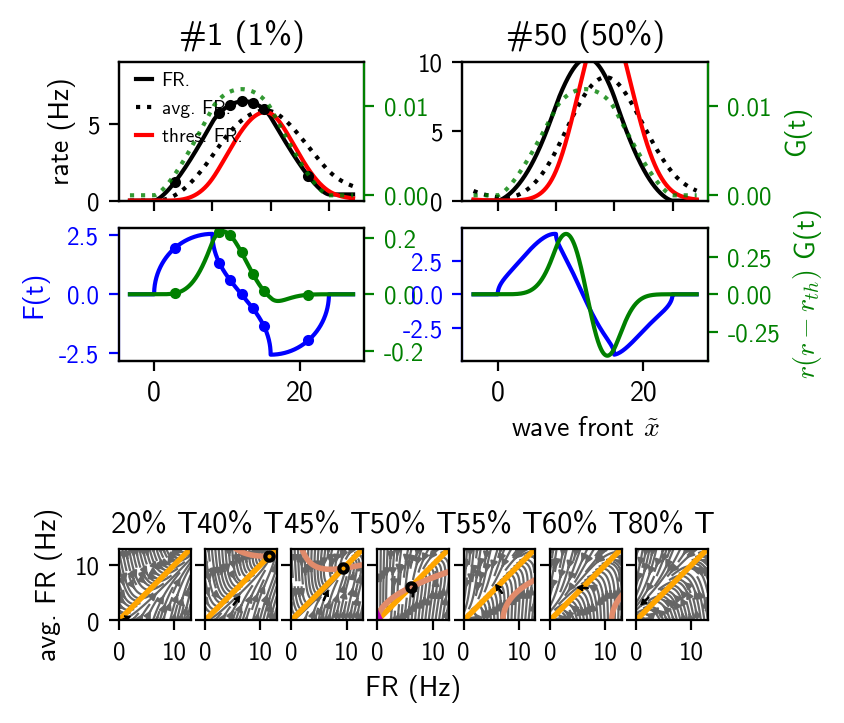

In [36]:
theme = 'mechanism-A011-100'
l = 8
deg_r = 10
tplot = False
#diagram_perc = [0.0] 0.5, 1.0]
diagram_perc = [0.0, 0.5]
pd = [0.2, 0.4, 0.45, 0.5, 0.55, 0.6, 0.8]
v = 3.2
#w_range = np.flipud(np.array([1.0, 0.66666667, 0.5, 0.4, 0.33333333])) * 0.16
#w_range = np.array([0.1, 0.15, 0.2, 0.25, 0.3])
#w_range = np.array([0.04, 0.07, 0.1, 0.13, 0.16, 0.19])
w_range = np.array([0.1])
#w_range = np.array([w_range[0]])
ltd_ratio_range = np.zeros(w_range.size) + 1
d_range = np.zeros(w_range.size) + 5
nT_0 = 100
#nT_range = np.array([int(nT_0*w_range[i]/w_range[w_range.size//2]) for i in range(w_range.size)])
nT_range = np.zeros(w_range.size, dtype = int) + nT_0
v_range = np.zeros(w_range.size) + v
fork_ivp = True 
dT = 1
dt = 5e-3
k = 0.114*0.017
A = 0.05
rx = 20
gL = 40
nx = 101
norm_w = 0
i = 0
method = 'approx2'
__d = d_range[i]/deg_r*l
_nT = nT_range[i]
_w0 = w_range[i]
_rLTD = ltd_ratio_range[i]
L = l*2*np.sqrt(2) + 2*__d
T = L/v
nt = int(T/dt)
wt1, fr1, rbar1, dt, Gt, G0, Ft = iter_sweep(method, nT = _nT, w0 = _w0, l = l, d = __d, v = v_range[i], k = k, A = A*_w0, rLTD = _rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, plot = tplot, theme = f'{theme}_{i}', fork_ivp = fork_ivp, shape = shape, reverse = 1, norm_w = norm_w, nt = nt, reset_fr = True, diagram_perc = diagram_perc, fs = 10, ls = 8, pdiagram_idx = 0, pd = pd, pscale = 2, less = 2, return_FG = True)

mechanism-A005-100
0.1


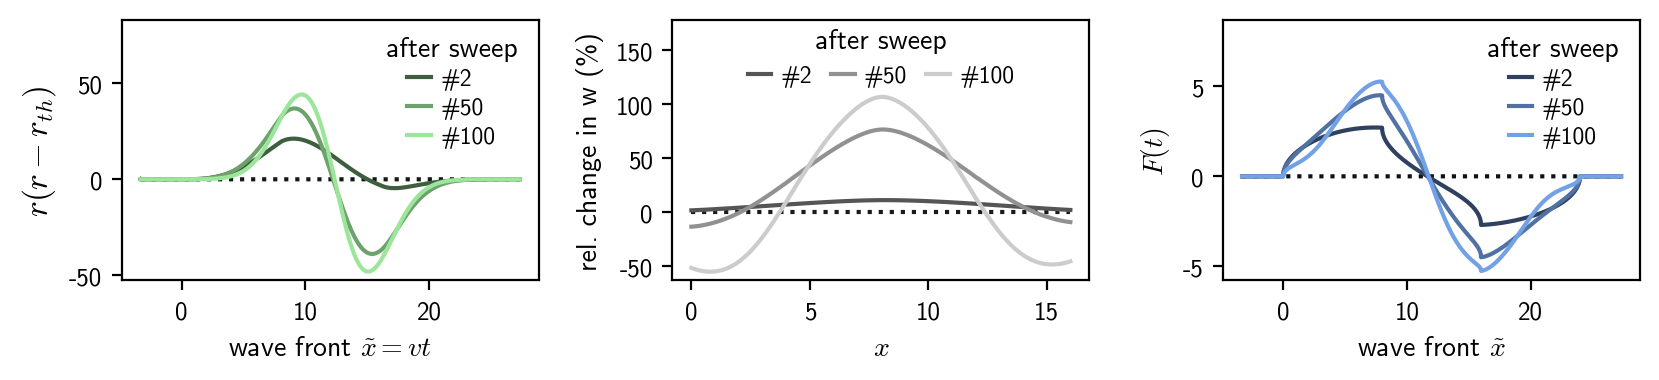

In [37]:
print(theme)
diagram_perc = [0.02, 0.5, 1.0]
greens, reds, blues, blacks = get_colors(len(diagram_perc)+1, sat0 = 0.5, val0 = 0.1, val1 = 0.9, sat_mode = False, g_sat_scale = 0.65)
nx = wt1.shape[0]
pi = 0
#diagram_perc = [0.0]
print(_w0)
t = np.arange(nt+1)*dt
x = np.linspace(0,2*l,nx)
fig = plt.figure(figsize = (2.8*3,2), dpi = 200)
thax = fig.add_subplot(131)
wax = fig.add_subplot(132)
fax = fig.add_subplot(133)
wax.plot(x, np.zeros_like(x), ':', c = blacks[0,:])
thax.plot(t*v-(np.sqrt(2)-1)*l, np.zeros_like(t), ':', c = greens[0,:])
fax.plot(t*v-(np.sqrt(2)-1)*l, np.zeros_like(t), ':', c = blues[0,:])
for p in diagram_perc:
    j = int(round(p*nT_0))
    if j == 0:
        j += 1
    sl = slice((j-1)*nt, j*nt+1)
    match method:
        case 'approx1'|'approx2'|'approx3':
            wax.plot(x, (wt1[:,j]-_w0)/_w0*100, c = blacks[pi+1,:], label = f'#{j}')
            #ax.plot(x, wt1[:,j]-_w0, c = blacks[pi+1,:], label = f'#{j}')
        case 'exact0'|'exact1'|'exact2':
            wax.plot(x, (wt1[:,j*nt]-_w0)/_w0*100, c = blacks[pi+1,:], label = f'#{j}')
            #ax.plot(x, (wt1[:,j*nt]-_w0), c = blacks[pi+1,:], label = f'#{j}')
    thax.plot(t*v-(np.sqrt(2)-1)*l, fr1[sl]*(fr1[sl]-rbar1[sl]/r0*rbar1[sl]), c = greens[pi+1,:], label = f'#{j}')
    fax.plot(t*v-(np.sqrt(2)-1)*l, Ft[sl], c = blues[pi+1,:], label = f'#{j}')
    pi += 1
wax.set_ylim(top = max(np.diff(wax.get_ylim()), wax.get_ylim()[1]*1.5))
wax.legend(fontsize = 8.5, handlelength = 1, title = 'after sweep', frameon = False, ncols = len(diagram_perc), loc = 'lower center', bbox_to_anchor = (0.5, 0.66), columnspacing = 0.8, handletextpad = 0.4)
wax.set_xlabel(r'$x$', fontsize = 10)
wax.set_ylabel('rel. change in w (%)', fontsize = 10)
#ax.set_ylabel(r'$\Delta w$', fontsize = 10)
wax.tick_params(axis = 'both', labelsize = 9)
thax.set_xlabel(r'wave front $\tilde{x}=vt$', fontsize = 10)
thax.set_ylabel(r'$r(r-r_{th})$', fontsize = 12)
thax.tick_params(axis = 'both', labelsize = 9)
thax.set_ylim(top = thax.get_ylim()[1]*1.7)
thax.legend(fontsize = 8.5, handlelength = 1, title = 'after sweep', frameon = False, ncols = 1, loc = 'upper right', columnspacing = 1, bbox_to_anchor = (1.0, 1.02), labelspacing = 0.3, handletextpad = 0.4)
fax.set_ylabel(r'$F(t)$', fontsize = 10)
fax.set_xlabel(r'wave front $\tilde{x}$', fontsize = 10)
fax.tick_params(axis = 'both', labelsize = 9)
fax.set_ylim(top = fax.get_ylim()[1]*1.5)
fax.legend(fontsize = 8.5, handlelength = 1, title = 'after sweep', frameon = False, ncols = 1, loc = 'upper right', columnspacing = 1, bbox_to_anchor = (1.0, 1.02), labelspacing = 0.3, handletextpad = 0.4)
fig.tight_layout()
fig.savefig(f'{theme}-1-{nT_0}w.svg')
fig.savefig(f'{theme}-1-{nT_0}w.png')